# Análise Focada na Ásia: Volume e Margem por Categoria e Subcategoria

Neste notebook, filtramos os dados exclusivamente para os países da Região **Asia**. O objetivo é detalhar o volume de vendas (número de produtos vendidos) e a rentabilidade (Gross Margin %) ao longo dos anos, primeiro ao nível da Categoria Principal e depois ao nível da Subcategoria.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)

# 1. Carregar os dados
df = pd.read_csv('../data/sales_data_clean.csv')

# Calcular Gross Margin % se não existir
if 'Gross_Margin' not in df.columns:
    df['GP'] = df['Sales_Price'] - df['Production_Cost']
    df['Gross_Margin'] = (df['GP'] / df['Sales_Price']) * 100

# 2. Filtrar apenas para a Ásia
df_asia = df[df['Region'] == 'Asia'].copy()

print(f"Total de vendas na Ásia: {len(df_asia):,}")
print(f"Países presentes na Ásia: {', '.join(df_asia['Country'].astype(str).unique())}")


Total de vendas na Ásia: 36,295
Países presentes na Ásia: Japan, South Korea, China, nan


## 1. Análise por Categoria Principal

### 1.1 Número Total de Produtos Vendidos (Volume) por País, Ano e Categoria

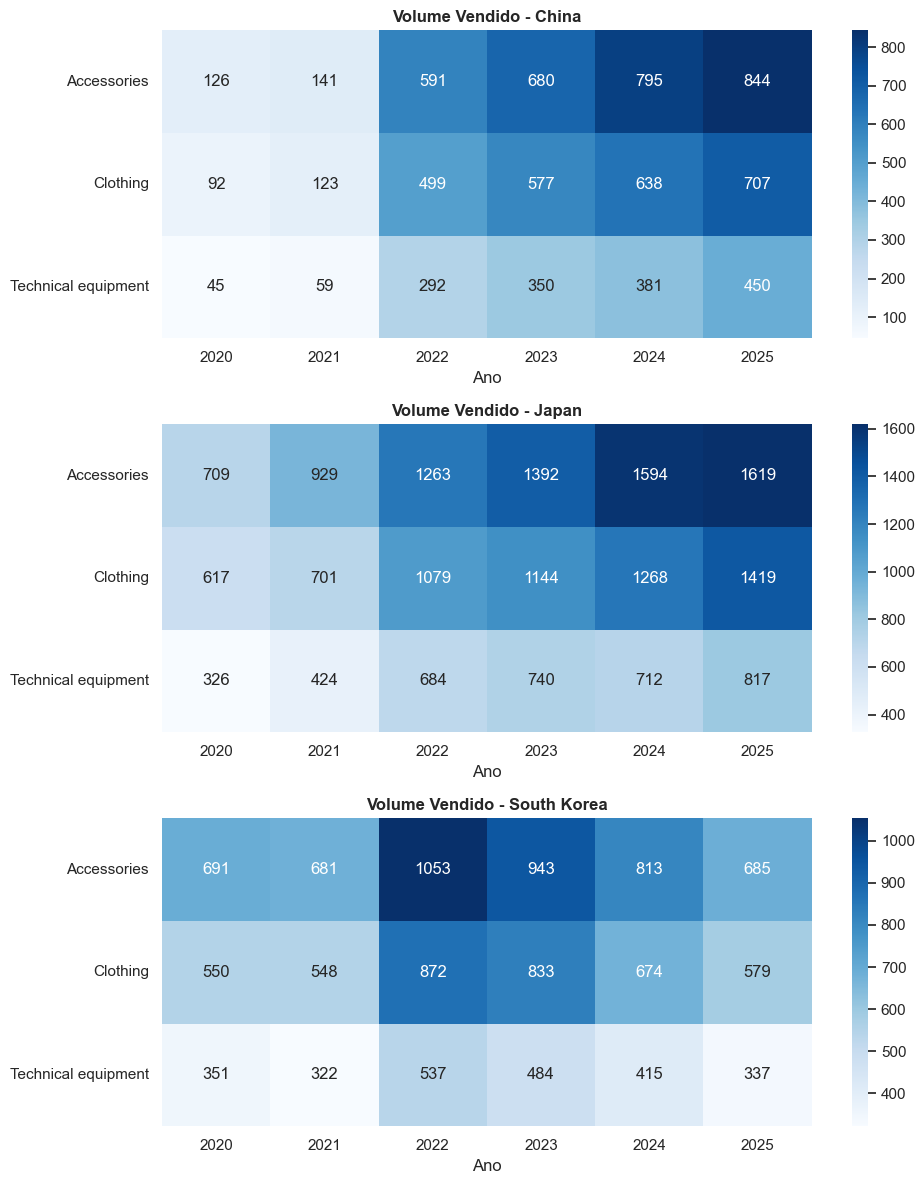

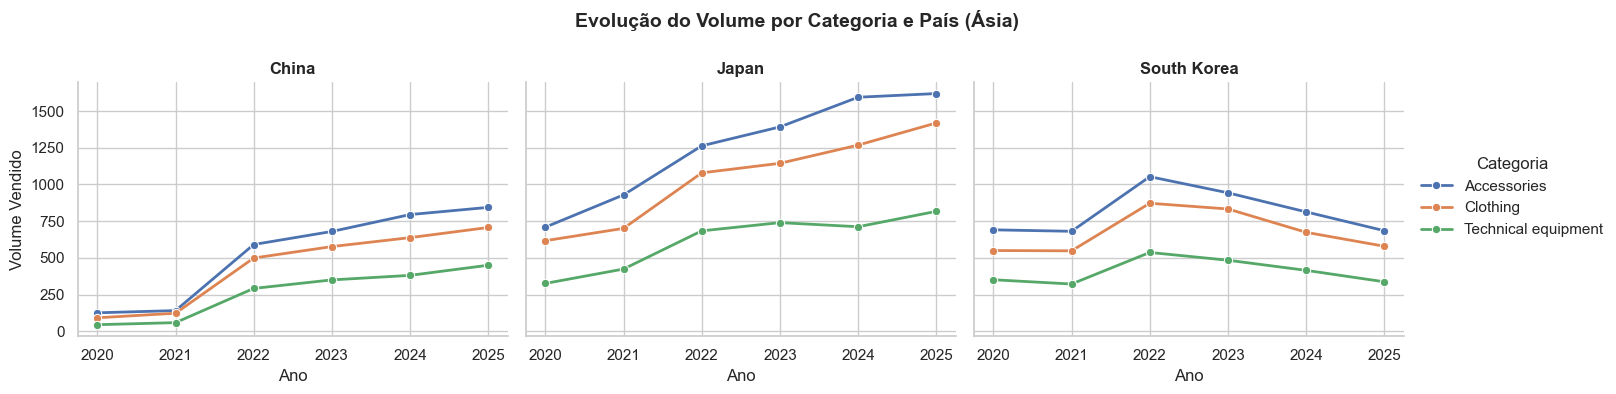

In [2]:
# Agrupar Volume por País, Ano e Categoria Principal
vol_cat = df_asia.groupby(['Country', 'Year', 'Main_Category'])['Sales_Order_ID'].count().reset_index(name='Volume')

# Pivot table para facilitar visualização no Heatmap
# Vamos focar na evolução temporal por Categoria dentro de cada País
countries = vol_cat['Country'].unique()

fig, axes = plt.subplots(len(countries), 1, figsize=(10, 4 * len(countries)))
if len(countries) == 1:
    axes = [axes]

for i, country in enumerate(countries):
    d = vol_cat[vol_cat['Country'] == country]
    pivot = d.pivot(index='Main_Category', columns='Year', values='Volume').fillna(0)
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Volume Vendido - {country}', fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Ano')

plt.tight_layout()
plt.show()

# Alternativa: Gráfico de linhas (Evolução)
g = sns.FacetGrid(vol_cat, col='Country', hue='Main_Category', height=4, aspect=1.2)
g.map(sns.lineplot, 'Year', 'Volume', marker='o', linewidth=2)
g.add_legend(title='Categoria')
g.set_axis_labels("Ano", "Volume Vendido")
g.set_titles(col_template="{col_name}", fontweight='bold')
for ax in g.axes.flatten():
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Evolução do Volume por Categoria e País (Ásia)', fontweight='bold', fontsize=14)
plt.show()


### 1.2 Margem (%) por País, Ano e Categoria Principal

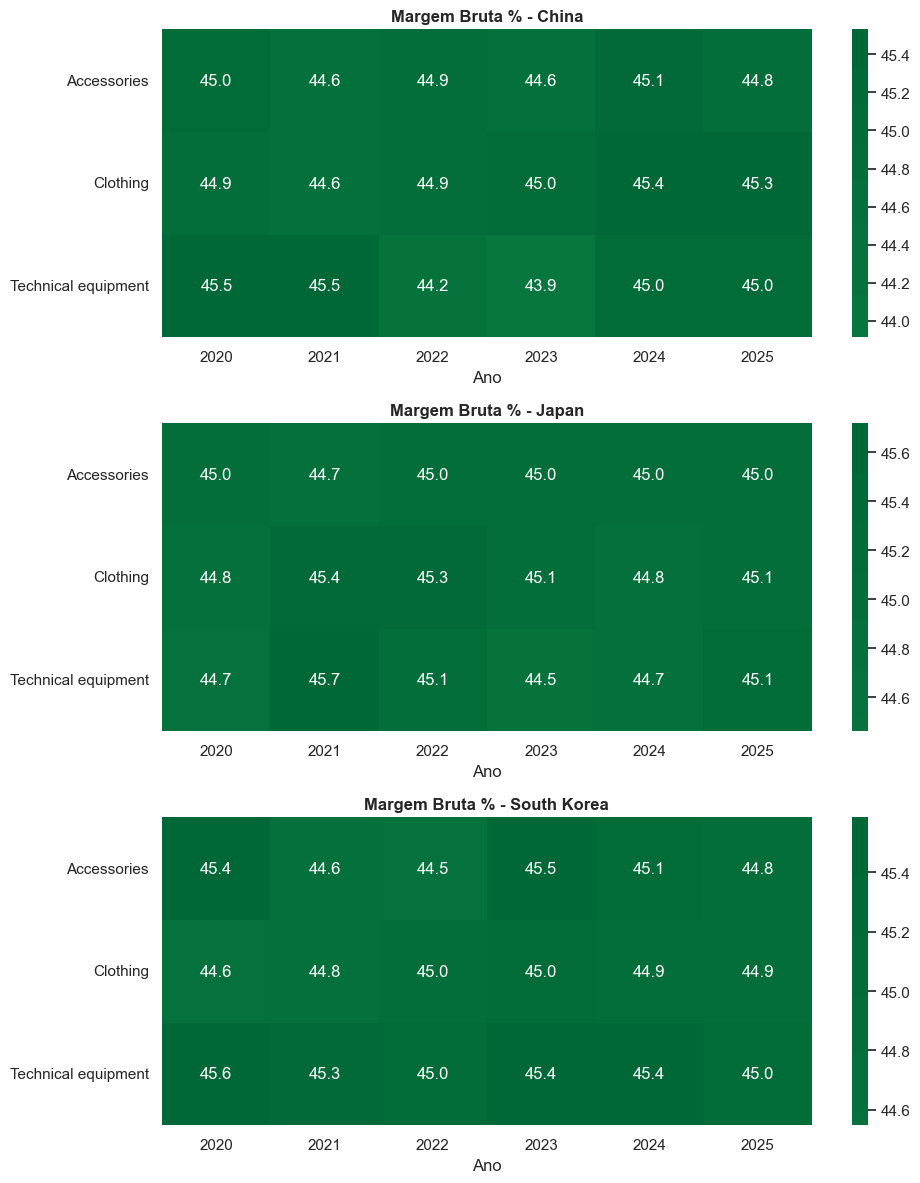

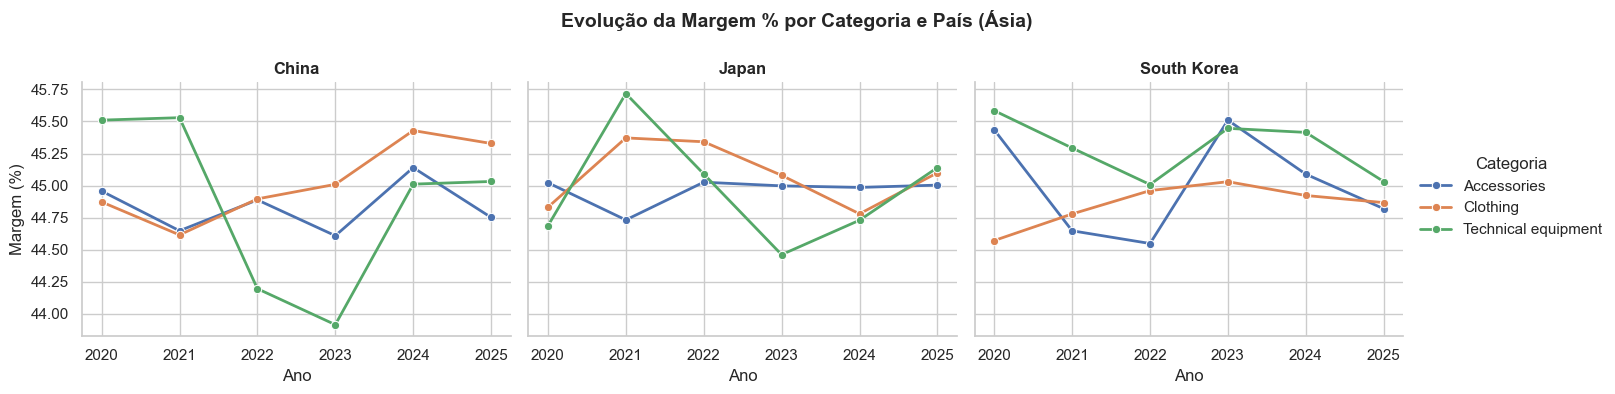

In [5]:
# Agrupar Margem por País, Ano e Categoria Principal
margin_cat = df_asia.groupby(['Country', 'Year', 'Main_Category'])['Gross_Margin'].mean().reset_index(name='Margin_pct')

fig, axes = plt.subplots(len(countries), 1, figsize=(10, 4 * len(countries)))
if len(countries) == 1:
    axes = [axes]

for i, country in enumerate(countries):
    d = margin_cat[margin_cat['Country'] == country]
    pivot = d.pivot(index='Main_Category', columns='Year', values='Margin_pct').fillna(0)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[i], center=20) # 20% threshold visual
    axes[i].set_title(f'Margem Bruta % - {country}', fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Ano')

plt.tight_layout()
plt.show()

# Gráfico de linhas (Evolução)
g = sns.FacetGrid(margin_cat, col='Country', hue='Main_Category', height=4, aspect=1.2)
g.map(sns.lineplot, 'Year', 'Margin_pct', marker='o', linewidth=2)
g.add_legend(title='Categoria')
g.set_axis_labels("Ano", "Margem (%)")
g.set_titles(col_template="{col_name}", fontweight='bold')
for ax in g.axes.flatten():
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Evolução da Margem % por Categoria e País (Ásia)', fontweight='bold', fontsize=14)
plt.show()


## 2. Análise por Subcategoria

### 2.1 Número Total de Produtos Vendidos (Volume) por País, Ano e Subcategoria

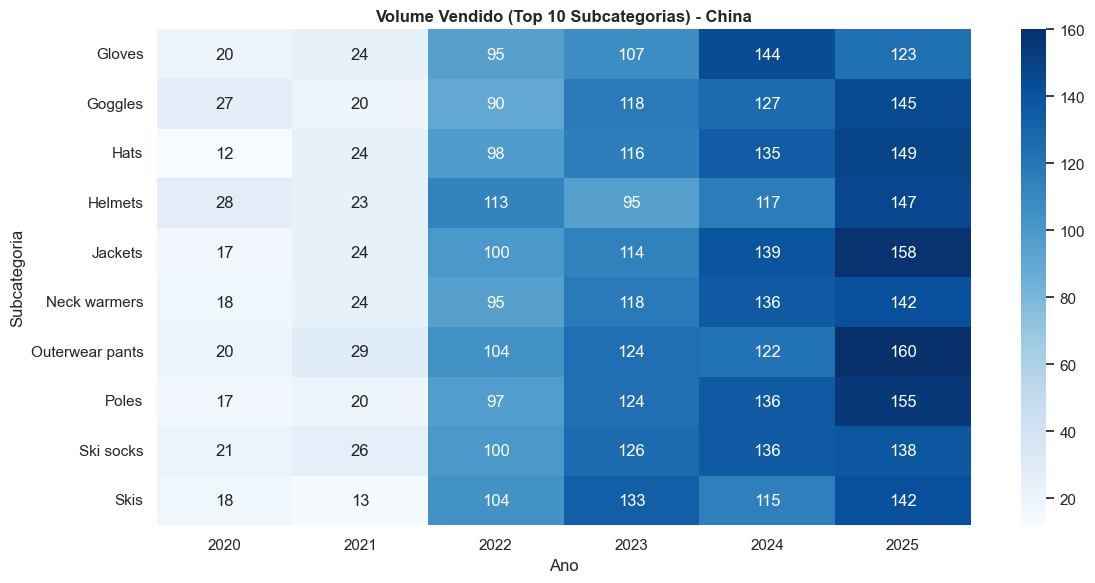

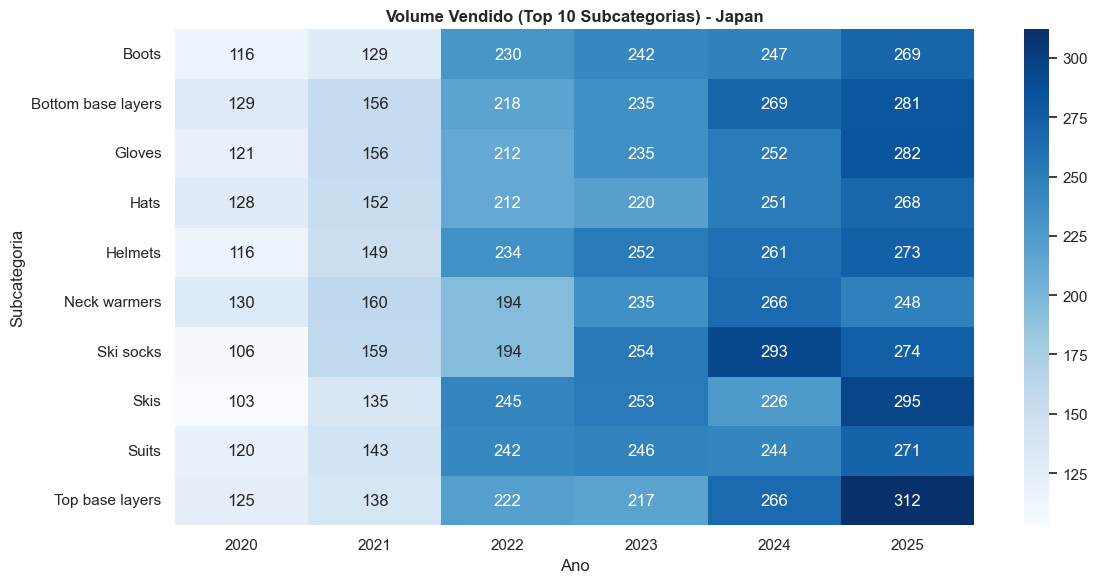

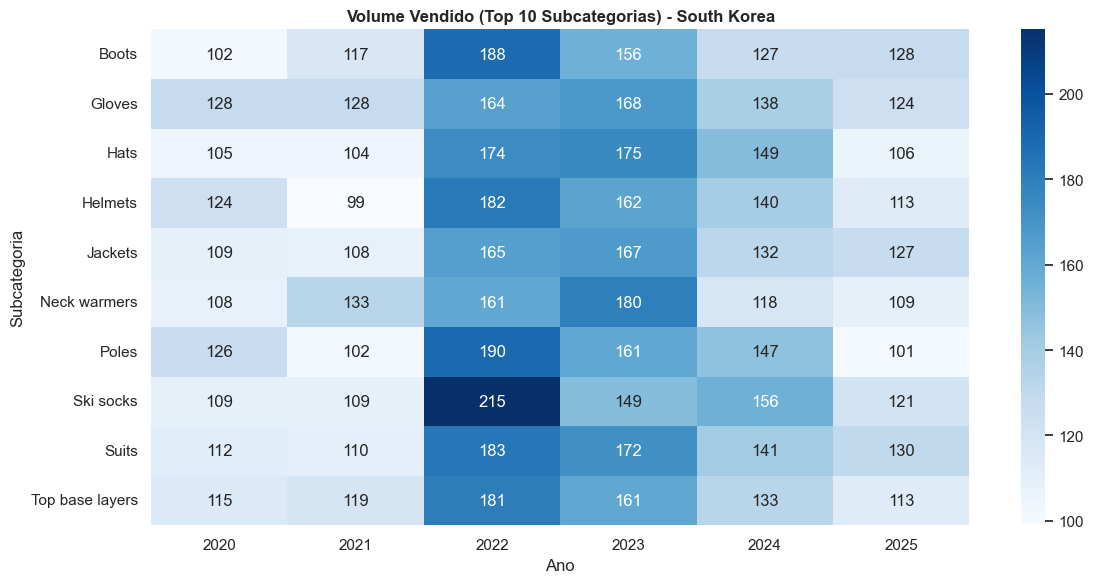

In [4]:
# Agrupar Volume por País, Ano e Subcategoria
vol_subcat = df_asia.groupby(['Country', 'Year', 'Subcategory'])['Sales_Order_ID'].count().reset_index(name='Volume')

# Para evitar gráficos demasiado longos, vamos mostrar apenas as Top 10 Subcategorias por País em Volume total
for country in countries:
    d = vol_subcat[vol_subcat['Country'] == country]
    top_subs = d.groupby('Subcategory')['Volume'].sum().nlargest(10).index
    d_top = d[d['Subcategory'].isin(top_subs)]
    
    plt.figure(figsize=(12, 6))
    pivot = d_top.pivot(index='Subcategory', columns='Year', values='Volume').fillna(0)
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
    plt.title(f'Volume Vendido (Top 10 Subcategorias) - {country}', fontweight='bold')
    plt.ylabel('Subcategoria')
    plt.xlabel('Ano')
    plt.tight_layout()
    plt.show()


### 2.2 Margem (%) por País, Ano e Subcategoria

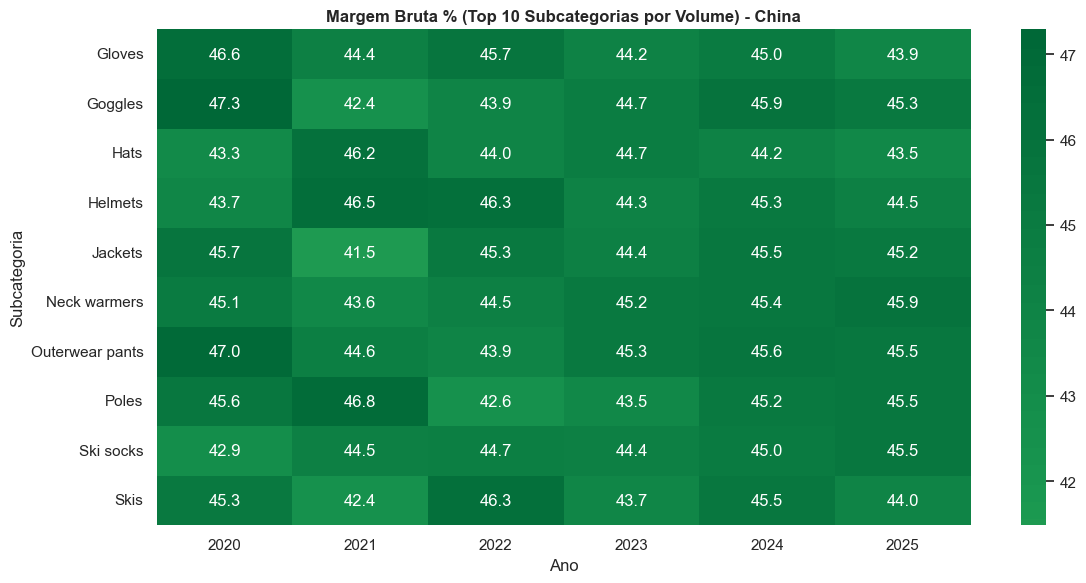

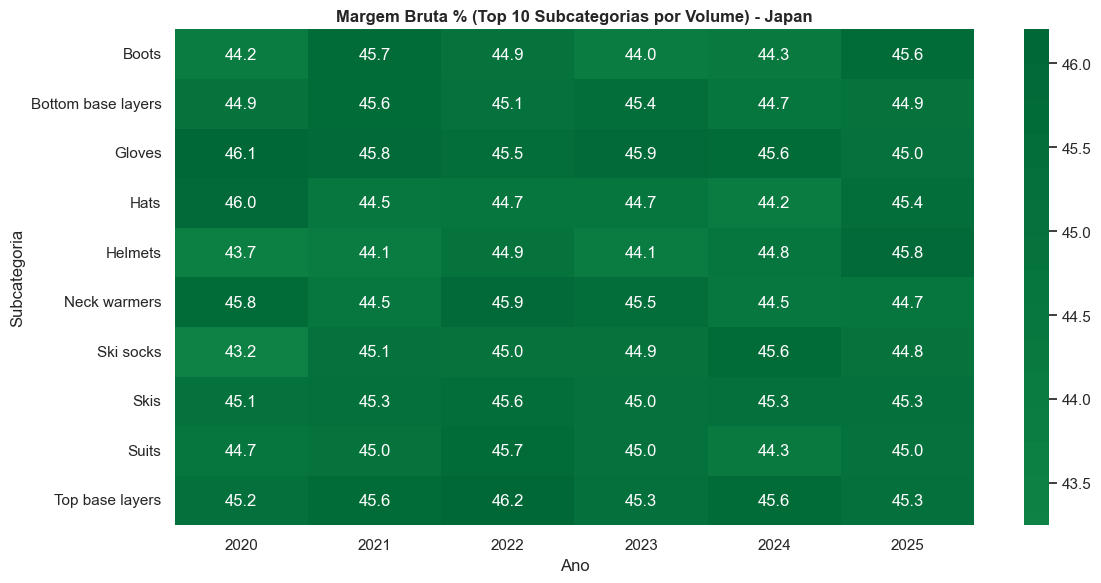

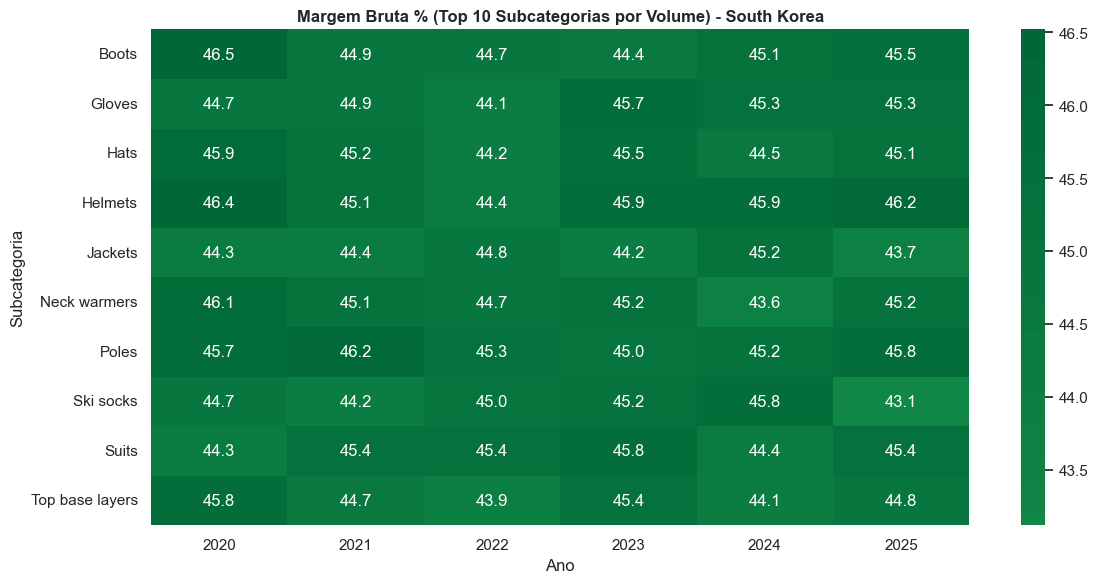

Subcategorias com Margem mais Crítica na Ásia em 2025:


Year  Margin_pct
Country     Subcategory                         
South Korea Ski socks           2025       43.12
China       Hats                2025       43.47
South Korea Jackets             2025       43.68
            Skis                2025       43.70
China       Gloves              2025       43.86
            Skis                2025       43.95
South Korea Goggles             2025       44.06
Japan       Goggles             2025       44.27
South Korea Bottom base layers  2025       44.38
Japan       Poles               2025       44.44
China       Helmets             2025       44.50
Japan       Neck warmers        2025       44.66
South Korea Top base layers     2025       44.78
Japan       Ski socks           2025       44.81
China       Suits               2025       44.86

In [5]:
# Agrupar Margem por País, Ano e Subcategoria
margin_subcat = df_asia.groupby(['Country', 'Year', 'Subcategory'])['Gross_Margin'].mean().reset_index(name='Margin_pct')

# Mostrar Heatmap para as mesmas Top 10 Subcategorias identificadas no bloco anterior
for country in countries:
    d_vol = vol_subcat[vol_subcat['Country'] == country]
    top_subs = d_vol.groupby('Subcategory')['Volume'].sum().nlargest(10).index
    
    d_margin = margin_subcat[(margin_subcat['Country'] == country) & (margin_subcat['Subcategory'].isin(top_subs))]
    
    plt.figure(figsize=(12, 6))
    pivot = d_margin.pivot(index='Subcategory', columns='Year', values='Margin_pct').fillna(0)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=20)
    plt.title(f'Margem Bruta % (Top 10 Subcategorias por Volume) - {country}', fontweight='bold')
    plt.ylabel('Subcategoria')
    plt.xlabel('Ano')
    plt.tight_layout()
    plt.show()
    
# Tabela com as Piores Margens por Subcategoria no último ano (2025)
print("Subcategorias com Margem mais Crítica na Ásia em 2025:")
d_2025 = margin_subcat[margin_subcat['Year'] == 2025].sort_values('Margin_pct').head(15)
display(d_2025.round(2).set_index(['Country', 'Subcategory']))
